In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """두 계열의 평균 제곱근 오차 — ML 수업에서 쓰던 그 지표 그대로"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))


def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

print("사용 폰트:", FONT)

사용 폰트: DejaVu Sans


In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
if "df" not in globals() or "demand" not in df.columns:   # 이 미션만 따로 열어도 단독으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 영역(폴더 아이콘)에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 168시간 뒤로 이동시키는 것이 "1주일 전" 이라는 뜻이 된다
    _s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
    _y = _s.fillna(_s.shift(24 * 7))      # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
    df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
    df["is_imputed"] = df["functioning"].eq("No")

FIT_START, TRAIN_END, VAL_END = "2018-09-01 00:00", "2018-11-16 23:00", "2018-11-23 23:00"
VAL_START = pd.Timestamp(TRAIN_END) + pd.Timedelta(hours=1)   # 검증은 학습이 끝난 바로 다음 시각부터
y_train = df["demand"].loc[FIT_START:TRAIN_END]     # 쓸 변수 1 — 학습 구간 보정 수요 (대/시간)
y_valid = df["demand"].loc[VAL_START:VAL_END]       # 쓸 변수 2 — 검증 구간 실측 (대/시간)

ORDER, SEASONAL_ORDER = (1, 0, 1), (1, 1, 1, 24)    # 오늘 쓸 차수: SARIMA(1, 0, 1)(1, 1, 1)₂₄
LAST_SEASONAL = (0, 1, 0, 24)                       # 어제 쓴 계절 차수 (P, D, Q, m): 계절차분만 있고 계절 AR·MA 가 없다
FIT_OPTS = "trend=None, enforce_stationarity=True, enforce_invertibility=True"

_fits = {}                                          # 두 차수를 같은 학습 구간에 각각 한 번씩 적합한다
for _name, _seas in (("어제", LAST_SEASONAL), ("오늘", SEASONAL_ORDER)):
    _fits[_name] = SARIMAX(y_train, order=ORDER, seasonal_order=_seas, trend=None,
                           enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)
_aic = {_name: _fit.aic for _name, _fit in _fits.items()}
_last_pred = _fits["어제"].get_forecast(steps=len(y_valid)).predicted_mean   # 어제 차수로 같은 168시간을 한 번에

print(f"학습 {FIT_START} ~ {TRAIN_END}   {len(y_train):,}시간   평균 {y_train.mean():,.1f} 대/시간   "
      f"채운 시각 {int(df['is_imputed'].loc[FIT_START:TRAIN_END].sum())}시간")
print(f"검증 {VAL_START:%Y-%m-%d %H:%M} ~ {VAL_END}   {len(y_valid):,}시간   "
      f"평균 {y_valid.mean():,.1f} 대/시간   채운 시각 {int(df['is_imputed'].loc[VAL_START:VAL_END].sum())}시간")
print(f"오늘 쓸 차수 : 비계절 차수 ORDER = {ORDER} · 계절 차수 SEASONAL_ORDER = {SEASONAL_ORDER}")
print(f"어제 차수 {ORDER}{LAST_SEASONAL} AIC = {_aic['어제']:,.2f}"
      f"   →   오늘 차수 {ORDER}{SEASONAL_ORDER} AIC = {_aic['오늘']:,.2f}")
print(f"계절 항 2개를 더해 AIC 가 {_aic['어제'] - _aic['오늘']:,.2f} 내려갔습니다 —"
      f" 두 적합 모두 같은 학습 {len(y_train):,}시간입니다")
print(f"어제 차수로 같은 검증 168시간을 한 번에 예측한 RMSE = {rmse(y_valid, _last_pred):,.2f} 대"
      " — 고친 뒤 오늘 차수의 값과 비교합니다")
print(f"적합 옵션 통일 — {FIT_OPTS}")
print("보정 수요 df['demand'] 는 전 구간이 결측 없이 채워져 있습니다 —"
      " 비교할 규칙이 검증 시각 이전 값을 참조해야 하기 때문입니다.")
_p, _e = _fits["오늘"].params, _fits["오늘"].resid       # 오늘 모형의 계수 4개와 한 시간 뒤 예측 오차(잔차)
_d = df["demand"]; _z = _d - _d.shift(24)                # z = 지금 값 − 24시간 전 같은 시각 값
_h = pd.Timedelta(hours=1); _t = VAL_START                # 11월 17일 0시 예측을 항별로 나눠 본다
print(f"오늘 모형의 계수 4개 : φ₁ {_p['ar.L1']:.2f} · θ₁ {_p['ma.L1']:.2f} · Φ₁ {_p['ar.S.L24']:.2f} · Θ₁ {_p['ma.S.L24']:.2f}")
_terms = {"24시간 전 실측": _d[_t - 24*_h], "φ₁×z(1시간 전)": _p["ar.L1"] * _z[_t - _h],
          "θ₁×오차(1시간 전)": _p["ma.L1"] * _e[_t - _h], "Φ₁×z(24시간 전)": _p["ar.S.L24"] * _z[_t - 24*_h],
          "Θ₁×오차(24시간 전)": _p["ma.S.L24"] * _e[_t - 24*_h],
          "곱 항 2개": -_p["ar.L1"] * _p["ar.S.L24"] * _z[_t - 25*_h] + _p["ma.L1"] * _p["ma.S.L24"] * _e[_t - 25*_h]}
print("11월 17일 0시 예측을 항별로 :", " · ".join(f"{k} {v:+,.1f}" for k, v in _terms.items()),
      f"= {sum(_terms.values()):,.1f} 대 (모형 출력 {_fits['오늘'].get_forecast(1).predicted_mean.iloc[0]:,.1f} 대)")
print("   손으로 더한 값과 모형 출력이 1대쯤 다른 것은 모형이 학습 첫 시각부터 이어 온 계산 상태로 예측하기 때문입니다.")
print("이 셀이 두 번 적합하므로 10초 남짓 걸립니다. 그대로 두고 기다리세요.")
print("쓸 수 있는 이름 : df (표 전체, 보정 수요는 demand 열) · y_train (학습 구간 보정 수요, 대/시간)"
      " · y_valid (검증 구간 실측, 대/시간) · ORDER · SEASONAL_ORDER (오늘 쓸 차수 2벌)"
      " · FIT_OPTS (적합 옵션 문자열) · SARIMAX · rmse(실측, 예측) · datefmt(ax, 표기, 눈금 수)")

학습 2018-09-01 00:00 ~ 2018-11-16 23:00   1,848시간   평균 986.6 대/시간   채운 시각 247시간
검증 2018-11-17 00:00 ~ 2018-11-23 23:00   168시간   평균 694.2 대/시간   채운 시각 0시간
오늘 쓸 차수 : 비계절 차수 ORDER = (1, 0, 1) · 계절 차수 SEASONAL_ORDER = (1, 1, 1, 24)
어제 차수 (1, 0, 1)(0, 1, 0, 24) AIC = 25,209.34   →   오늘 차수 (1, 0, 1)(1, 1, 1, 24) AIC = 24,502.69
계절 항 2개를 더해 AIC 가 706.65 내려갔습니다 — 두 적합 모두 같은 학습 1,848시간입니다
어제 차수로 같은 검증 168시간을 한 번에 예측한 RMSE = 271.22 대 — 고친 뒤 오늘 차수의 값과 비교합니다
적합 옵션 통일 — trend=None, enforce_stationarity=True, enforce_invertibility=True
보정 수요 df['demand'] 는 전 구간이 결측 없이 채워져 있습니다 — 비교할 규칙이 검증 시각 이전 값을 참조해야 하기 때문입니다.
오늘 모형의 계수 4개 : φ₁ 0.78 · θ₁ 0.31 · Φ₁ 0.29 · Θ₁ -1.00
11월 17일 0시 예측을 항별로 : 24시간 전 실측 +683.0 · φ₁×z(1시간 전) -26.6 · θ₁×오차(1시간 전) +14.9 · Φ₁×z(24시간 전) +21.1 · Θ₁×오차(24시간 전) -93.4 · 곱 항 2개 +24.7 = 623.6 대 (모형 출력 624.6 대)
   손으로 더한 값과 모형 출력이 1대쯤 다른 것은 모형이 학습 첫 시각부터 이어 온 계산 상태로 예측하기 때문입니다.
이 셀이 두 번 적합하므로 10초 남짓 걸립니다. 그대로 두고 기다리세요.
쓸 수 있는 이름 : df (표 전체, 보정 수요는 demand 열) · y_train (학습 구간 보정 수요, 대/시

검증 168시간 RMSE = 386.08 대
1주일 전 값 규칙의 RMSE = 205.25 대


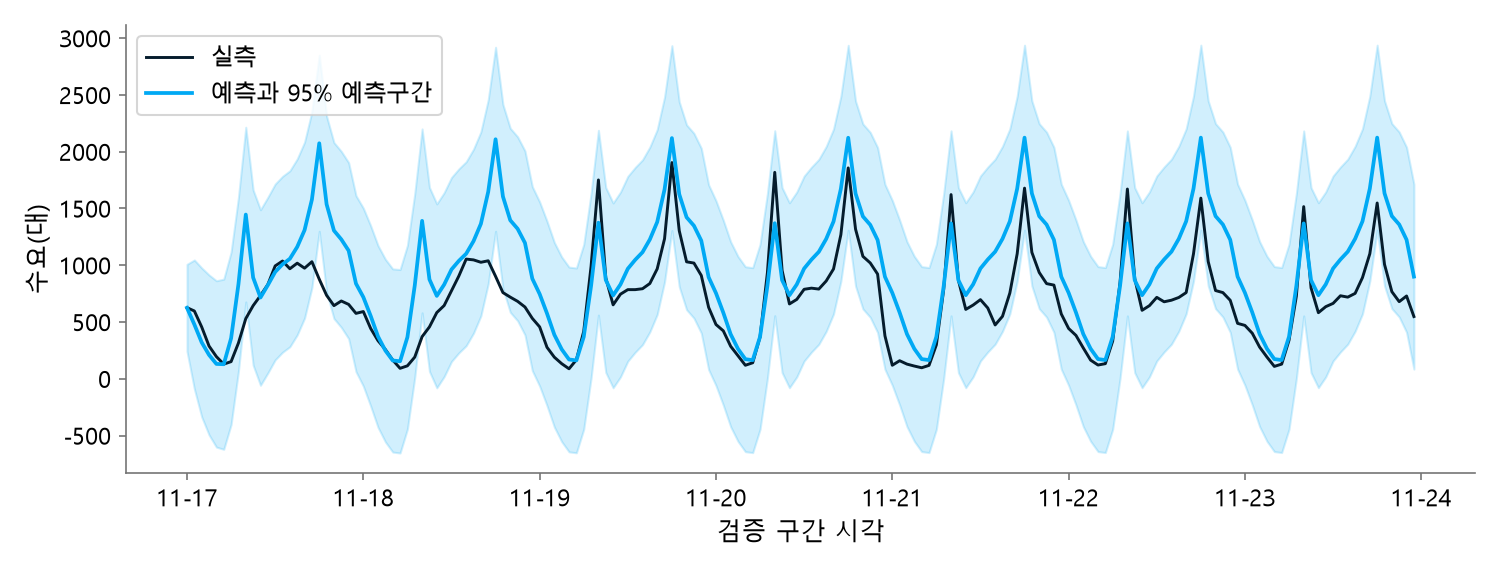

In [4]:
# 미션 1 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 값 하나가 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 표시선 아래를 다시 씁니다.
PROMPT = """
전임 담당자의 코드가 지금 잘못 작성되어 있어서 수정이 필요한 상태임
내가 점검했을 땐 shift(24)가 168로 수정 필요한 것으로 확인됨(24의 경우 하루 전 기준인데 일주일 전 기준은 168임)
해당 부분 수정하면서 아래 추출 필요한 부분 추출될 수 있도록 코드를 짜야해

1. 168시간 검증 RMSE: 단위 대, 수수점 아래 2자리, SARIMA 모형 168시간 한번에 예측해 검증 구간에서 받은 값
2. 1주일 전 값 규칙의 RMSE: 단위 대, 소수점 아래 2자리, demand를 168시간 뒤로 이동시켜 만든 예측이 같은 168시간에서 받은 값
3. 그래프
선 2개: 검증 168시간의 실측선 하나, 같은 구간의 예측선 하나, 두 선은 다른 색으로 설정하고 범례로 어느 쪽이 실측인지 표시
채움 영역: 98% 예측구간의 아래쪽 경계와 위쪽 경계 사이를 옅은 색으로 채움
가로축 이름: '검증 구각 시간', 날짜 표기는 detefmt(ax, "%m-%d", 8)처럼 그래프를 그린 ax와 표기와 눈금 수를 전달해 정리
세로축 이름: '수요(대)'
"""
# --- 여기부터 AI 코드 ---
# ↓ 전임 담당자의 코드 — 그대로 실행하면 채점이 ❌ 를 냅니다
res = SARIMAX(y_train, order=ORDER, seasonal_order=SEASONAL_ORDER, trend=None,
              enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)
fc = res.get_forecast(steps=len(y_valid))       # 학습 구간 끝 다음 시각부터 한 번에 168시간
ci = fc.conf_int(alpha=0.05)                    # 95% 예측구간
pred = np.asarray(fc.predicted_mean, dtype=float)

naive = df["demand"].shift(168).loc[y_valid.index]   # 1주일 전 같은 시각 값을 그대로 산출하는 규칙
print(f"검증 168시간 RMSE = {rmse(y_valid, pred):,.2f} 대")
print(f"1주일 전 값 규칙의 RMSE = {rmse(y_valid, naive):,.2f} 대")

fig, ax = plt.subplots(figsize=(FIG_W, 3.8))
ax.fill_between(y_valid.index, ci.iloc[:, 0], ci.iloc[:, 1], color=COL["하늘색"], alpha=0.18)
ax.plot(y_valid.index, y_valid, color=COL["남색"], lw=1.4, label="실측")
ax.plot(y_valid.index, pred, color=COL["하늘색"], lw=1.8, label="예측과 95% 예측구간")
ax.legend()
ax.set_xlabel("검증 구간 시각")
ax.set_ylabel("수요(대)")
datefmt(ax, "%m-%d", 8)
plt.show()

# 고친 뒤 같은 168시간에서 오차가 더 작은 쪽은 어디일까요?

2. 계절 나이브 168: 1주일 전 같은 시각의 실측을 그대로 써서 최근 수준을 

사유: 계절 나이브 168 기준으로 RMSE가 205.25대로 검즘 168시간의 RMSE 386.08보다 오차가 작다.

# 계절 항 2개를 더해 AIC 가 706.65 내려간 것을 읽기
「준비 셀」은 어제 차수 (1, 0, 1)(0, 1, 0, 24) 의 AIC 25,209.34 와 오늘 차수 (1, 0, 1)(1, 1, 1, 24) 의 AIC 24,502.69 를 함께 출력했습니다. 두 값의 차이 706.65 를 읽는 방법으로 맞는 것은?

B. 같은 1,848시간에서 계산한 점수라 비교할 수 있고, 차이가 2 를 크게 넘어 계절 항을 더한 쪽을 고른다


AIC 는 학습 구간에서 계산한 점수입니다. 검증 구간의 오차와는 다른 물음에 답합니다.
「준비 셀」의 두 AIC 는 같은 계열의 같은 1,848시간으로 계산했습니다. 이론이 정한 대로 차이가 2 이하면 항이 적은 쪽을 고르는데, 706.65 는 그 선을 크게 넘습니다. 그래서 24시간 전 같은 시각의 값과 잔차를 보는 항 2개를 더한 쪽이 오늘의 차수가 됐습니다.
첫째 보기: AIC 는 한 시간 뒤를 맞힌 결과로, 검증 오차는 168시간을 내리 예측한 결과로 계산합니다. AIC 가 706.65 내려간 차수인데도 검증 168시간 RMSE 는 386.08대로, 계절 나이브 168 의 205.25대보다 컸습니다. 어제 차수의 271.22대보다도 115대 컸습니다.
셋째 보기: AIC 는 작을수록 좋은 점수입니다. 학습 구간을 잘 설명할수록 작아지고, 계수를 하나 더 쓸 때마다 2 씩 커집니다. 그래서 24,502.69 를 받은 오늘 차수가 더 나은 쪽입니다.

내 결과로 확인하는 법: 「준비 셀」이 출력한 두 AIC 를 빼 706.65 가 되는지 봅니다.
문서에 적을 때: 「학습 1,848시간 · (1,0,1)(0,1,0,24) AIC 25,209.34 → (1,0,1)(1,1,1,24) AIC 24,502.69 · 하락 706.65」처럼 구간과 두 차수를 값과 함께 적습니다.
핵심 키워드: 같은 계열·같은 구간에서 계산한 점수, 작을수록 좋다, 검증 구간 오차는 따로 측정

# 미션 1 의 출력에는 SARIMA 모형의 RMSE 와 계절 나이브 168 의 RMSE 가 나란히 출력되었습니다. 두 숫자를 비교하는 방법으로 맞는 것은?
미션 1 의 출력에는 SARIMA 모형의 RMSE 와 계절 나이브 168 의 RMSE 가 나란히 출력되었습니다. 두 숫자를 비교하는 방법으로 맞는 것은?

B. 둘 다 11월 16일 23시에서 168시간을 예측해 비교할 수 있고, SARIMA 모형의 오차가 더 컸다

두 예측 모두 11월 16일 23시에서 168시간 뒤를 예측했습니다. 그래서 나란히 비교할 수 있습니다.
검증 168시간의 출력으로 확인합니다. SARIMA 모형의 RMSE 는 386.08대이고 계절 나이브 168 은 205.25대입니다. 규칙 쪽이 절반 수준입니다. 하루씩 나눠 보아도 7일 전부에서 규칙 쪽 오차가 작습니다.
첫째 보기: 규칙은 검증 구간 안의 실측을 사용하지 않습니다. 168시간 뒤로 이동시킨 계열은 11월 17일 0시에 11월 10일 0시의 실측을 배치합니다. 그 168개 값은 전부 11월 16일 23시 이전, 곧 학습 구간 안에 있습니다.
셋째 보기: 규칙도 1시간 뒤가 아니라 168시간 뒤까지 예측합니다. 예측 기간이 짧은 규칙의 오차가 더 작은 것은 맞습니다. 직전 값을 내는 규칙은 286.60대, 24시간 전 값을 내는 규칙은 245.45대로 SARIMA 모형보다 작습니다. 그러나 이 둘은 검증 구간 안의 실측을 각각 167시간·144시간 사용합니다. 오늘 조건에서 측정한 값이 아닙니다.

내 결과로 확인하는 법: 두 RMSE 를 하루씩 나눠 다시 계산해 7일 전부에서 규칙 쪽이 작은지 봅니다.
문서에 적을 때: 「예측 원점(예측을 시작한 시각) 11월 16일 23시 · 예측 기간 168시간 · 검증 168시간 · SARIMA 386.08대 · 계절 나이브 168 205.25대」처럼 예측 원점과 예측 기간을 값과 함께 적습니다.
핵심 키워드: 같은 168시간 예측 기간, 규칙이 참조하는 값은 전부 학습 구간 안, 오늘 설정에서 예측 기간이 다른 규칙은 순위에서 제외한다

# 미션 1 의 그림에서 예측선 위아래를 채운 옅은 영역이 95% 예측구간입니다. 11월 17일 0시의 영역은 241대부터 1,008대까지인데, 이 범위를 읽는 방법으로 맞는 것은?

C. 11월 17일 0시에 기록될 수요 한 값이 그 사이에 들어올 확률을 95% 로 본 범위다

예측구간은 다음 관측 하나가 들어올 범위입니다. 평균 수준의 범위는 신뢰구간이라 답하는 물음이 다릅니다.
미션 1 의 그림에서 첫 시각 예측은 624.6대, 범위는 241.2～1,008.0대, 구간 길이는 766.8대입니다. 같은 구간이 168시간 뒤에는 1,629.1대로 2.12배가 됩니다. 길어지는 까닭은 먼 시각을 예측할수록 다음 값 하나의 불확실성이 커지기 때문입니다.
첫째 보기: 평균 수준의 범위인 신뢰구간은 관측이 많아질수록 짧아지고, 몇 시간 뒤인지가 커져도 길어지지 않습니다. 미션 1 의 영역은 1시간 뒤에서 168시간 뒤까지 2.12배가 됐습니다.
둘째 보기: 이 범위의 길이는 실측을 보고 정한 값이 아닙니다. 적합한 모형의 예측 오차 표준편차에 1.96 을 곱해 계산합니다. 96.4% 는 그렇게 계산한 구간이 결과적으로 담은 비율입니다.

내 결과로 확인하는 법: ci 의 첫 행 두 값을 출력해 그림의 옅은 영역과 대조합니다. 실측이 그 안에 든 시간이 몇 시간인지도 계산해 봅니다.
문서에 적을 때: 「11월 17일 0시 예측 624.6대 · 95% 예측구간 241.2～1,008.0대 · 검증 168시간 가운데 162시간 포함」처럼 점 예측과 구간과 포함 시간을 함께 적습니다.
핵심 키워드: 다음 값 하나가 들어올 범위, 평균 수준의 범위는 신뢰구간, 내건 95% 와 담은 96.4% 는 다른 수

In [5]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals() or "demand" not in df.columns:   # 과제만 따로 열어도 단독으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 영역(폴더 아이콘)에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 168시간이 곧 7일이라는 뜻이 된다
    _s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
    _y = _s.fillna(_s.shift(24 * 7))      # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
    df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
    df["is_imputed"] = df["functioning"].eq("No")

FIT_START, TRAIN_END, VAL_END = "2018-09-01 00:00", "2018-11-16 23:00", "2018-11-23 23:00"
VAL_START = pd.Timestamp(TRAIN_END) + pd.Timedelta(hours=1)
y_train = df["demand"].loc[FIT_START:TRAIN_END]     # 학습 구간 보정 수요 (대/시간)
y_valid = df["demand"].loc[VAL_START:VAL_END]       # 검증 구간 실측 (대/시간)
ORDER, SEASONAL_ORDER = (1, 0, 1), (1, 1, 1, 24)    # 미션 1 과 같은 차수: SARIMA(1, 0, 1)(1, 1, 1)₂₄

_res = SARIMAX(y_train, order=ORDER, seasonal_order=SEASONAL_ORDER, trend=None,
               enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)
_f = _res.get_forecast(steps=len(y_valid))          # 미션 1 과 같이 168시간을 한 번에
_ci = _f.conf_int(alpha=0.05)                       # 95% 예측구간
fc = pd.DataFrame({"actual": np.asarray(y_valid, dtype=float),
                   "pred": np.asarray(_f.predicted_mean, dtype=float),
                   "lo95": np.asarray(_ci.iloc[:, 0], dtype=float),
                   "hi95": np.asarray(_ci.iloc[:, 1], dtype=float)}, index=y_valid.index)
fc["width"] = fc["hi95"] - fc["lo95"]               # 쓸 변수 1 — 168행 예측표 (구간 길이 width 열 포함)
resid = _res.resid.iloc[24:]                        # 쓸 변수 2 — 계절차분으로 z 가 없는 앞 24시간을 뗀 잔차
_theta = float(_res.params["ma.S.L24"])             # 계절 이동평균(seasonal MA) 계수 Θ₁ — −1.00 이면 먼 시각 예측이 시각별 평균에 가까워진다
_hour_mean = y_train.groupby(y_train.index.hour).mean()        # 학습 11주의 시각별 평균
_gap = float(np.abs(fc["pred"].iloc[-24:].values - _hour_mean.loc[fc.index[-24:].hour].values).max())

_n_covered = int(((fc["actual"] >= fc["lo95"]) & (fc["actual"] <= fc["hi95"])).sum())
print(f"예측표 fc — {len(fc)}행 x {fc.shape[1]}열   "
      f"{fc.index.min():%m-%d %H시} ~ {fc.index.max():%m-%d %H시}")
print("이 예측표는 미션 1 과 같은 적합에서 나온 결과라, 미션 1 과 같은 값이 나옵니다.")
_w = fc["width"]
print(f"구간 길이 — 첫 시각 {_w.iloc[0]:,.1f} 대 → 첫날 끝 {_w.iloc[23]:,.1f} 대 → 둘째 날 끝 {_w.iloc[47]:,.1f} 대 "
      f"→ 마지막 시각 {_w.iloc[-1]:,.1f} 대 ({_w.iloc[-1] / _w.iloc[0]:.2f}배)")
print("구간은 첫날 안에 대부분 길어지고, 그 뒤로는 조금씩만 늡니다.")
print(f"계절 이동평균(seasonal MA) 계수 Θ₁ 이 {_theta:.2f} 이라, 먼 시각의 예측이 학습 11주의 시각별 평균으로 돌아갑니다.")
print(f"마지막 날 예측과 그 시각별 평균의 차이는 시각마다 {np.ceil(_gap):.0f}대 안쪽입니다.")
print(f"95% 예측구간이 포함한 실측 — {_n_covered}/{len(fc)}시간 ({_n_covered / len(fc):.1%})")
print(f"잔차 {len(resid):,}개 (계절차분으로 첫 24시간이 빠진 수) · 표준편차 {resid.std():,.1f} 대")
print("검정 도구 : acorr_ljungbox(잔차, lags=[24], model_df=4) — 돌려주는 표의 lb_stat 과 lb_pvalue 두 열")
print("            귀무가설은 「시차 24까지 자기상관이 없다」 이고, model_df 4 는 계수 4개(φ₁ · θ₁ · Φ₁ · Θ₁)를 자유도에서 뺀다는 뜻")
print("적합에 10초 안팎 걸렸습니다. 아래 「PROMPT 셀」은 이 변수들만 쓰고 다시 적합하지 않습니다.")
print("쓸 수 있는 이름 : fc (168행 예측표 — actual · pred · lo95 · hi95 · width, width 가 구간 길이) · resid (잔차)"
      " · y_valid (검증 실측) · df (표 전체) · acorr_ljungbox · rmse(실측, 예측) · mae(실측, 예측)"
      " · datefmt(ax, 표기, 눈금 수)")

예측표 fc — 168행 x 5열   11-17 00시 ~ 11-23 23시
이 예측표는 미션 1 과 같은 적합에서 나온 결과라, 미션 1 과 같은 값이 나옵니다.
구간 길이 — 첫 시각 766.8 대 → 첫날 끝 1,550.3 대 → 둘째 날 끝 1,620.5 대 → 마지막 시각 1,629.1 대 (2.12배)
구간은 첫날 안에 대부분 길어지고, 그 뒤로는 조금씩만 늡니다.
계절 이동평균(seasonal MA) 계수 Θ₁ 이 -1.00 이라, 먼 시각의 예측이 학습 11주의 시각별 평균으로 돌아갑니다.
마지막 날 예측과 그 시각별 평균의 차이는 시각마다 18대 안쪽입니다.
95% 예측구간이 포함한 실측 — 162/168시간 (96.4%)
잔차 1,824개 (계절차분으로 첫 24시간이 빠진 수) · 표준편차 200.4 대
검정 도구 : acorr_ljungbox(잔차, lags=[24], model_df=4) — 돌려주는 표의 lb_stat 과 lb_pvalue 두 열
            귀무가설은 「시차 24까지 자기상관이 없다」 이고, model_df 4 는 계수 4개(φ₁ · θ₁ · Φ₁ · Θ₁)를 자유도에서 뺀다는 뜻
적합에 10초 안팎 걸렸습니다. 아래 「PROMPT 셀」은 이 변수들만 쓰고 다시 적합하지 않습니다.
쓸 수 있는 이름 : fc (168행 예측표 — actual · pred · lo95 · hi95 · width, width 가 구간 길이) · resid (잔차) · y_valid (검증 실측) · df (표 전체) · acorr_ljungbox · rmse(실측, 예측) · mae(실측, 예측) · datefmt(ax, 표기, 눈금 수)


11월 17일 00시 · 예측 625 대 · 하한 241 · 상한 1,008 · 구간 길이 767 · 확신
11월 17일 01시 · 예측 478 대 · 하한 -89 · 상한 1,046 · 구간 길이 1,136 · 확신
11월 17일 02시 · 예측 320 대 · 하한 -336 · 상한 976 · 구간 길이 1,312 · 확신
11월 17일 03시 · 예측 210 대 · 하한 -494 · 상한 914 · 구간 길이 1,409 · 확신
11월 17일 04시 · 예측 131 대 · 하한 -602 · 상한 863 · 구간 길이 1,465 · 확신
11월 17일 05시 · 예측 128 대 · 하한 -621 · 상한 877 · 구간 길이 1,499 · 확신
11월 17일 06시 · 예측 357 대 · 하한 -403 · 상한 1,116 · 구간 길이 1,519 · 보류
11월 17일 07시 · 예측 833 대 · 하한 67 · 상한 1,598 · 구간 길이 1,531 · 보류
11월 17일 08시 · 예측 1,446 대 · 하한 677 · 상한 2,215 · 구간 길이 1,539 · 보류
11월 17일 09시 · 예측 891 대 · 하한 120 · 상한 1,663 · 구간 길이 1,543 · 보류
11월 17일 10시 · 예측 716 대 · 하한 -57 · 상한 1,489 · 구간 길이 1,546 · 보류
11월 17일 11시 · 예측 824 대 · 하한 51 · 상한 1,598 · 구간 길이 1,548 · 보류
11월 17일 12시 · 예측 941 대 · 하한 167 · 상한 1,715 · 구간 길이 1,549 · 보류
11월 17일 13시 · 예측 1,008 대 · 하한 234 · 상한 1,783 · 구간 길이 1,549 · 보류
11월 17일 14시 · 예측 1,057 대 · 하한 282 · 상한 1,832 · 구간 길이 1,550 · 보류
11월 17일 15시 · 예측 1,161 대 · 하한 386 · 상한 1,936 · 구간 길이 1,550 · 보류
11월 17일

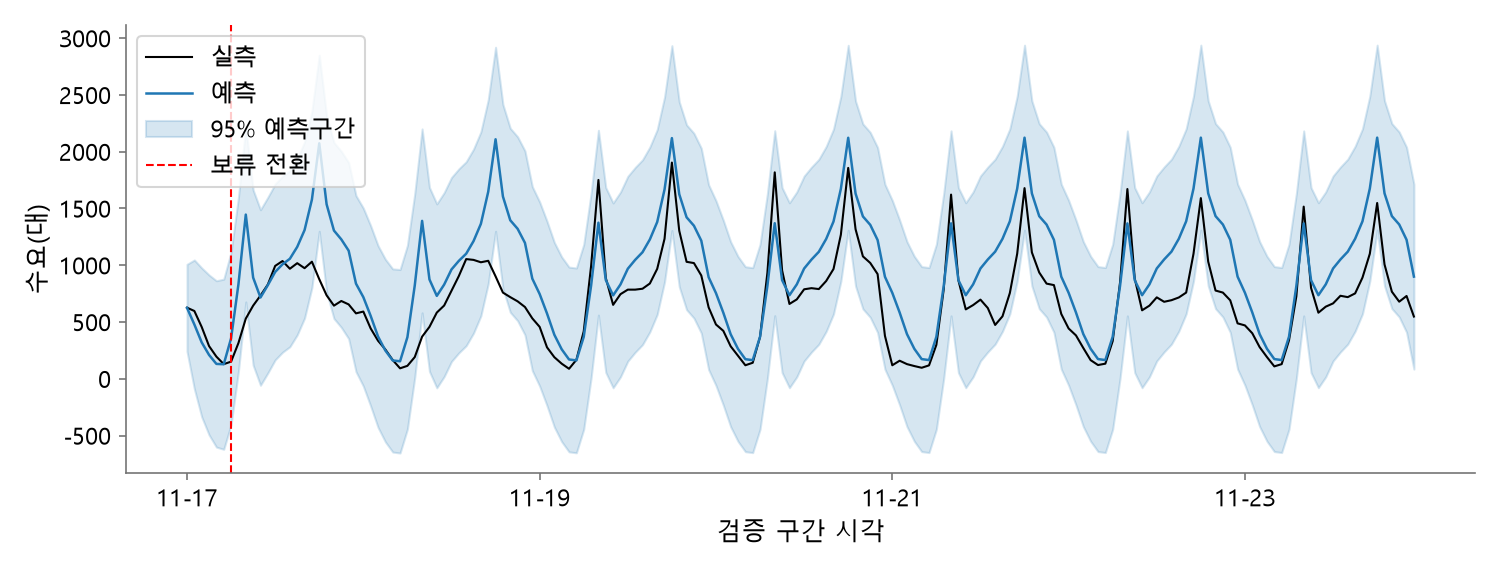

In [9]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
아래 내용으로 추출될 수 있도록 코드 작성해줘
1. 인수인계표: 검증 168마다 시각, 예측, 하한, 상한, 구간 길이, 등급까지 열 6개를 갖춤
구간 길이가 구분 기준값보다 짧은 시각이 확신, 나머지가 보류
2. 인수인계표 행 수: 단위 행, 정수
3. 확신으로 남은 시각 수: 단위 시간, 정수, '확신 = OO시간'처럼 그 단어를 값과 같은 출력 행에 둠
4. 보류로 남은 시각 수: 단위 시간, 정수, '보류 = OO시간'처럼 그 단어를 값과 같은 출력 행에 둠
5. 하한이 음수인 시각 수: 단위 시간, 정수, lo95가 0보다 작은 행의 개수
6. 잔차 Ljung-Box 시차 24 통계량: 소수점 아래 2자리 resid에 시차 24, model_df 4로 적용한 검정의 lb_stat
7. 잔차 Ljung-Box 시차 24 p 값: 같은 검정의 lb_pvalue
8 그래프
선: 168시간의 예측선 1개, 실측선을 겹쳐서 그림
채움영역: 95% 예측구간의 아래쪽 경계와 위쪽 경계 사이를 옅은 색으로 채움
세로선: 등급이 처음 보류로 바뀌는 시각에 세로축 전체에 걸친 선 하나
가로축 이름: 검증 구간 시각
세로축 이름: 수요(대)

나는 구분 기준값을 1500대로 설정할게
"""
# --- 여기부터 AI 코드 ---
threshold = 1500
fc["등급"] = np.where(fc["width"] < threshold, "확신", "보류")

handoff = fc[["pred", "lo95", "hi95", "width", "등급"]].copy()
handoff.columns = ["예측", "하한", "상한", "구간 길이", "등급"]
for t, row in handoff.iterrows():
    print(f"{t:%m월 %d일 %H시} · 예측 {row['예측']:,.0f} 대 · 하한 {row['하한']:,.0f} · 상한 {row['상한']:,.0f} · 구간 길이 {row['구간 길이']:,.0f} · {row['등급']}")

print(f"\n인수인계표 행 수: {len(handoff)} 행")

n_confident = (fc["등급"] == "확신").sum()
n_hold = (fc["등급"] == "보류").sum()
print(f"확신 = {n_confident}시간")
print(f"보류 = {n_hold}시간")

n_neg_lo = (fc["lo95"] < 0).sum()
print(f"하한이 음수인 시각 수: {n_neg_lo} 시간")

lb = acorr_ljungbox(resid, lags=[24], model_df=4, return_df=True)
lb_stat = round(lb["lb_stat"].iloc[0], 2)
lb_pvalue = lb["lb_pvalue"].iloc[0]
print(f"잔차 Ljung-Box 시차 24 통계량 = {lb_stat}")
print(f"잔차 Ljung-Box 시차 24 p 값 = {lb_pvalue}")

switch_time = fc.index[fc["등급"] == "보류"][0]

fig, ax = plt.subplots(figsize=(FIG_W, 3.8))
ax.plot(fc.index, fc["actual"], label="실측", color="black", linewidth=1)
ax.plot(fc.index, fc["pred"], label="예측", color="tab:blue", linewidth=1.2)
ax.fill_between(fc.index, fc["lo95"], fc["hi95"], alpha=0.18, color="tab:blue", label="95% 예측구간")
ax.axvline(switch_time, color="red", linestyle="--", linewidth=1, label="보류 전환")
ax.set_xlabel("검증 구간 시각")
ax.set_ylabel("수요(대)")
ax.legend()
datefmt(ax)
plt.tight_layout()
plt.show()

브리핑 세 문장: 아래 세 문장을 이 셀에 그대로 채워 제출합니다. 채점을 받기 전에 내 출력만 보고 먼저 채웁니다.

완성본의 숫자는 구분 기준값 예시 하나에서 나온 값이라 내 숫자와 달라도 됩니다. 완성본과는 세 문장이 결론·위험·방식을 각각 적었는지만 대조합니다.

결론: 확신으로 전달할 시각은 6시간이고 나머지 162시간은 보류입니다. 구분 기준값은 구간 길이 1500대로 정했고, 그 값을 정한 운영 근거는
구간 길이 1500대는 첫날이 끝나기 직전까지의 폭으로, 평소 아침 재배치 인력이 흡수해 온 수요 변동 범위 안에 들어 확신으로 분류했다. 둘째 날부터는 구간이 1550대를 넘어서며 재배치로 감당하기 어려운 폭이 되어 보류로 넘긴다.

위험: 구간이 음수일 뿐 예측값이 음수는 아님(하한이 음수인 55시간을 어떻게 적어 전달할지, 그리고 잔차 Ljung-Box 가 시차 24 에서 남긴 한계를 내 수치로 한 문장)

코드가 답을 만드는 방식: 등급 열: fc["width"](hi95 − lo95, 구간 길이)와 본인이 정한 기준값(1500)을 비교해서, width가 기준보다 작으면 "확신", 아니면 "보류"로 나눔 (등급 열을 어떤 열의 어떤 비교로 만들었는지, 그리고 확신과 보류의 경계인 세로선을 어느 시각에 그었는지 한 문장)

기준 값 설정 관련 예시

숫자 근거: 1500대가 실제 구간 길이 분포에서 어디쯤인지. fc["width"].describe()나 fc["width"].quantile([.25,.5,.75])를 찍어서, 1500이 전체 범위(최소~최대) 중 어느 지점인지, 몇 시간이 그보다 짧은지 확인해 보세요. "중앙값 근처"인지 "상위 30%만 넘는 값"인지에 따라 쓸 문장이 달라집니다.

운영 의미: 왜 하필 그 폭까지는 배차팀이 감당 가능한지. 예를 들어 "하루 운행 대수 대비 몇 % 오차인지", 혹은 "당일 아침 추가 배차로 메울 수 있는 규모인지" 같은 현장 기준을 한 구로 덧붙이는 겁니다.

# 잔차 자기상관 막대 9개와 Ljung-Box p 값을 함께 읽기
오늘 차수의 잔차 1,824개(계절차분으로 첫 24시간이 빠진 수)에 Ljung-Box 를 시차 24 로 적용하면 통계량 277.46 · p 값 3.16e-47 이 나옵니다. 같은 잔차의 자기상관을 시차 36 까지 계산하면 경계선(우연으로 볼 수 있는 범위의 경계) ±0.046 밖 막대가 9개입니다. 두 결과로 내리는 결론으로 맞는 것은?

A. 막대 9개는 규칙 없는 오차인 백색잡음(white noise)에서 기대하는 1.8개(36 × 0.05)의 5배이고 p 값도 0.05 보다 작으니, 남은 자기상관을 한계로 적는다


두 진단은 같은 물음을 다른 방법으로 묻습니다. 하나는 시차마다 막대 하나로, 다른 하나는 시차 24개를 한 수로 모아 묻습니다.

검정의 p 값 3.16e-47 은 기준 0.05 보다 작아 「시차 24까지 자기상관이 없다」는 귀무가설이 기각됩니다. 막대 쪽도 같은 방향입니다. 경계선 ±0.046 은 1.96 을 잔차 1,824개의 제곱근으로 나눈 값입니다. 가장 크게 벗어난 막대는 시차 10 의 +0.32 입니다. 검정 범위 밖인 시차 168 의 자기상관은 0.386 으로 더 큽니다. 1주일 전 같은 시각과의 관계가 잔차에 남았습니다.

둘째 보기: p 값이 작을수록 통과라고 읽은 것입니다. 이 검정의 귀무가설이 「자기상관이 없다」이므로 방향이 반대입니다. 3.16e-47 은 그 가설을 기각하는 값입니다. 자기상관이 없다는 결론은 p 값이 0.05 보다 클 때 내립니다.

셋째 보기: 경계선이 잔차 개수로 정해지는 것은 맞습니다. 다만 그 계산은 백색잡음을 전제로 한 95% 기준입니다. 시차 하나가 우연히 밖으로 나갈 확률은 잔차가 몇 개든 0.05 입니다. 그래서 기대 개수 36 × 0.05 = 1.8 도 잔차 개수와 무관합니다.

내 결과로 확인하는 법: resid 의 자기상관을 시차 36까지 계산해 절댓값이 0.046 을 넘는 시차가 몇 개인지 확인합니다.

문서에 적을 때: 「Ljung-Box 시차 24 통계량 277.46 · p 값 3.16e-47 · 시차 36 가운데 경계선 밖 막대 9개(기대 1.8개)」처럼 검정 결과와 막대 개수를 함께 적습니다.

핵심 키워드: p 값이 작으면 기각, 기대 개수 36 × 0.05 = 1.8, 두 진단이 같은 방향

#  나이브 168 보다 오차가 컸는데도 이 표를 배차팀에 전달하는 근거
오늘 SARIMA 모형은 검증 168시간에서 1주일 전 값을 그대로 내는 계절 나이브 168 보다 큰 오차를 받았습니다. 그런데도 SARIMA 모형의 예측과 95% 예측구간으로 만든 표를 배차팀에 함께 전달합니다. 그 판단의 근거로 맞는 것은?

C. 배차 대수는 오차가 작은 계절 나이브 168 로 내고, 이 표의 등급은 확정할 시각을 정하는 근거로 쓰기 때문이다

이번 주에 내보낼 숫자와 그 숫자를 언제 확정할지는 다른 물음입니다.

검증 168시간의 출력으로 확인합니다. RMSE 가 작았던 쪽은 계절 나이브 168 의 205.25대입니다. SARIMA 모형은 386.08대로 1.88배였습니다. 그래서 이번 주 배차 대수는 베이스라인 표에서 가져옵니다. SARIMA 표의 구간과 등급은 시각마다 따로 봅니다. 그 시각의 대수를 금요일에 확정할지, 당일 아침에 다시 정할지 판단하는 근거입니다. 다음 주에 같은 예측 기간으로 다시 측정할 때 비교 대상도 됩니다. 계절 나이브에도 과거 오차로 구간을 만드는 방법이 있습니다. 구간이 있다는 것만으로 이번 주 배차를 SARIMA 표로 정할 수는 없습니다. 그 표의 한계도 함께 적습니다. 95% 예측구간은 168시간 중 162시간에서 실측을 담았고, 잔차 Ljung-Box 는 시차 24 에서 p 값 3.16e-47 로 기각됐습니다.

첫째 보기: 우연이라고 말할 근거가 없습니다. 하루씩 나눠 보아도 검증 7일 전부에서 규칙 쪽 오차가 작았습니다. 다음 주 순위는 다시 측정해야 알 수 있습니다.

둘째 보기: AIC 는 검증 구간 오차의 순위를 말해 주지 않습니다. 오늘 차수의 AIC 24,502.69 는 학습 구간 1,848시간으로 계산한 점수입니다. 계절 나이브 168 은 계수를 하나도 추정하지 않아 AIC 가 없습니다. 두 방법을 AIC 로 비교하는 것 자체가 성립하지 않습니다.

내 결과로 확인하는 법: 회신 초안에 예측 기간 168시간과 두 RMSE 가 함께 적혀 있는지 봅니다.

문서에 적을 때: 「이 예측 기간, 이 검증 구간에서는 계절 나이브 168 이 더 정확했다. SARIMA 표는 예측구간과 등급을 함께 적어 첨부하고, 다음 주에도 168시간 뒤까지 다시 측정한다」처럼 측정 조건과 다음 회차를 함께 적습니다.

핵심 키워드: 이번 주 숫자는 오차가 작은 쪽, 구간과 등급은 함께 첨부, 다음 주에 다시 측정